In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("C:/Users/uditk/DeliveryDelayPrediction/DATA/DATA.csv")

In [5]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

# **CLEANING NUMERICAL COMUMNS**

In [20]:
df["Delivery_person_Age"] = pd.to_numeric(
    df["Delivery_person_Age"],
    errors="coerce"
)

In [21]:
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median()
)

In [23]:
df["Delivery_person_Ratings"] = pd.to_numeric(
    df["Delivery_person_Ratings"],
    errors="coerce"
)

In [24]:
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median()
)

In [25]:
df["multiple_deliveries"] = pd.to_numeric(
    df["multiple_deliveries"],
    errors="coerce"
)

In [26]:
df["multiple_deliveries"] = df["multiple_deliveries"].fillna(
    df["multiple_deliveries"].median()
)

In [27]:
df["Time_taken(min)"] = (
    df["Time_taken(min)"]
    .str.replace("(min) ", "", regex=False)
)

In [28]:

df["Time_taken(min)"] = pd.to_numeric(
    df["Time_taken(min)"],
    errors="coerce"
)

# **CLEANING CATEGORICAL COLUMN**

In [29]:
df["Road_traffic_density"] = (
    df["Road_traffic_density"]
    .replace("NaN ", pd.NA)
)

df["Road_traffic_density"] = (
    df["Road_traffic_density"]
    .fillna(df["Road_traffic_density"].mode()[0])
)

In [30]:
df["Festival"] = (
    df["Festival"]
    .replace("NaN", pd.NA)
)

df["Festival"] = (
    df["Festival"]
    .fillna(df["Festival"].mode()[0])
)

In [31]:
df["City"] = (
    df["City"]
    .replace("NaN", pd.NA)
)

df["City"] = (
    df["City"]
    .fillna(df["City"].mode()[0])
)

# **Creating Distance Feature**

In [33]:
df["distance"] = np.sqrt(
    (df["Restaurant_latitude"] -
     df["Delivery_location_latitude"])**2
    +
    (df["Restaurant_longitude"] -
     df["Delivery_location_longitude"])**2
)

# **EDA**

#### HISTOGRAM

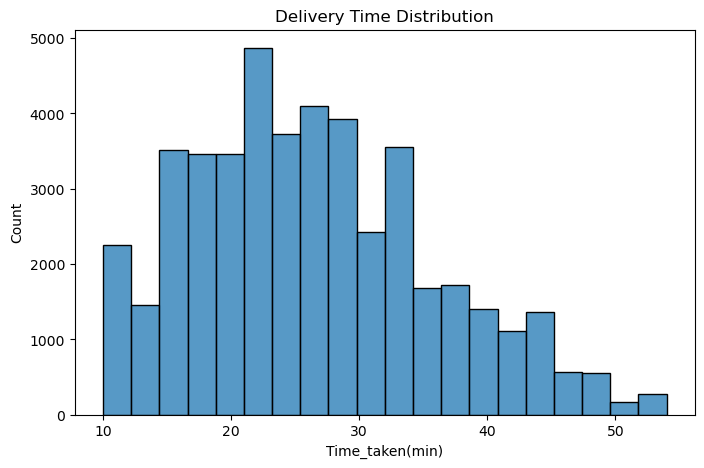

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Time_taken(min)"],
    bins=20
)

plt.title("Delivery Time Distribution")
plt.show()

#### Traffic VS Delivery Time

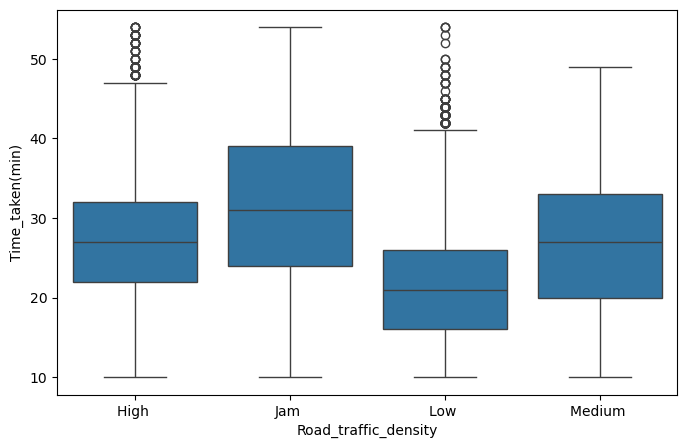

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Road_traffic_density",
    y="Time_taken(min)",
    data=df
)

plt.show()

#### Average Time by Traffic  

In [38]:
df.groupby(
    "Road_traffic_density"
)["Time_taken(min)"].mean()


Road_traffic_density
High       27.240000
Jam        31.176624
Low        21.464175
Medium     26.699644
Name: Time_taken(min), dtype: float64

#### Average Time by Weather

In [39]:
df.groupby(
    "Weatherconditions"
)["Time_taken(min)"].mean()

Weatherconditions
conditions Cloudy        28.917330
conditions Fog           28.916122
conditions NaN           26.545455
conditions Sandstorms    25.875517
conditions Stormy        25.870815
conditions Sunny         21.856947
conditions Windy         26.118836
Name: Time_taken(min), dtype: float64

#### Average Time by Multiple Deliveries

In [40]:
df.groupby(
    "multiple_deliveries"
)["Time_taken(min)"].mean()

multiple_deliveries
0.0    22.876268
1.0    26.716623
2.0    40.454912
3.0    47.819945
Name: Time_taken(min), dtype: float64

# ML 

In [41]:
y = df["Time_taken(min)"]

In [42]:
X = df.drop(
    columns=[
        "Time_taken(min)",
        "ID",
        "Delivery_person_ID",
        "Order_Date",
        "Time_Orderd",
        "Time_Order_picked"
    ]
)

In [43]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [44]:
X.isnull().sum().sum()

np.int64(0)

### TRAIN-TEST SPLIT

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### TRAIN MODEL

In [46]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### PREDICTIONS

In [47]:
predictions = model.predict(X_test)

#### EVALUATION

In [50]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 3.2279559162188836
RMSE: 4.080915826994138
R2  : 0.8100567073120621


#### FEATURE IMPORTANCE

In [51]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance.head(10))

Delivery_person_Ratings                    0.204325
multiple_deliveries                        0.120087
Road_traffic_density_Low                   0.103438
Delivery_person_Age                        0.097174
distance                                   0.094319
Weatherconditions_conditions Sunny         0.068595
Vehicle_condition                          0.067568
Weatherconditions_conditions Fog           0.033825
Weatherconditions_conditions Sandstorms    0.022760
Delivery_location_longitude                0.022607
dtype: float64


# **PLOTTING IMPORTANT FEATURES**

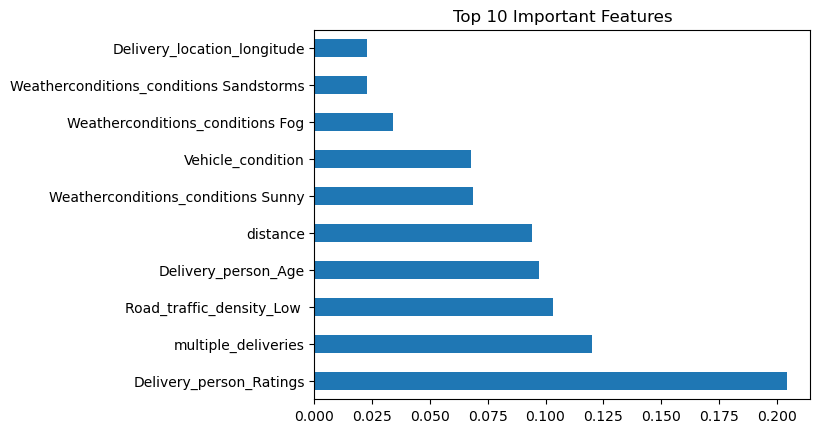

In [52]:
importance.head(10).plot(
    kind="barh"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()